In [124]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d, Delaunay


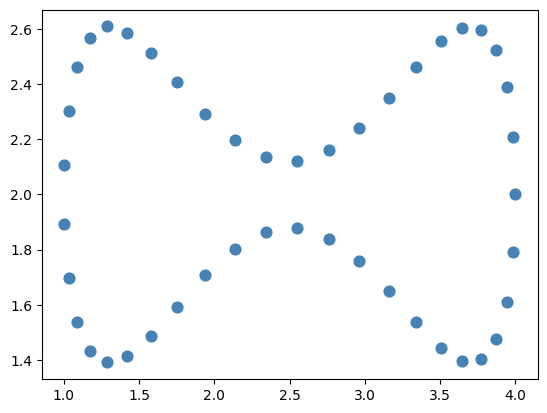

In [270]:
t = np.linspace(0, 2*np.pi, 45, endpoint=False)


x = np.cos(t) 
y = np.sin(t) * (0.15 + 1.75 * np.cos(t)**2)  # 0.3 sets the minimum thickness

x = 2.5 + 1.5*x
y = 2.0 + 0.8*y

points = list(zip(x, y))

x = [p[0] for p in points]
y = [p[1] for p in points]

fig, ax = plt.subplots()
ax.scatter(x, y, color='steelblue', s=60, zorder=3)

In [331]:
points

[(4.0, 2.0),
 (3.9854021031123557, 2.2077691825277608),
 (3.9418925439074783, 2.389650246151078),
 (3.8703181864639014, 2.5240360029489297),
 (3.772072144234639, 2.597144717568502),
 (3.6490666646784673, 2.605219067877227),
 (3.5036959095382874, 2.5550029062767408),
 (3.3387893552061203, 2.4624167508870856),
 (3.1575567201836163, 2.349664109974393),
 (2.963525491562421, 2.2412717243563565),
 (2.7604722665003956, 2.1597507525911843),
 (2.5523492450537515, 2.121631025320079),
 (2.34320730509852, 2.134555510119785),
 (2.1371171566004983, 2.1959383024326304),
 (1.9380901098761318, 2.29341858656986),
 (1.7500000000000004, 2.407031939778686),
 (1.5765077870115125, 2.5127228792716894),
 (1.4209902994920232, 2.5865901230328165),
 (1.286474508437579, 2.6091288492807663),
 (1.1755786107116095, 2.5687342978882644),
 (1.0904610688211376, 2.463858358687618),
 (1.0327785988992915, 2.3034433329867126),
 (1.0036539246102638, 2.105554634445955),
 (1.0036539246102638, 1.8944453655540454),
 (1.0327785988

In [271]:
points_array = np.array(points)
vor = Voronoi(points_array)
tri = Delaunay(points_array)

In [279]:
vertices = list(range(len(points)))

# 1-simplices
edges = set()

for simplex in tri.simplices:
    for i in range(3):
        for j in range(i + 1, 3):
            edge = tuple(sorted((simplex[i], simplex[j])))
            edges.add(edge)

edges = sorted(edges)

# 2-simplices
triangles = [tuple(sorted(s)) for s in tri.simplices]
triangles = sorted(triangles)


with open("complex.simp", "w") as f:
    # Vertices
    for v in vertices:
        f.write(f"{v}\n")

    # Edges
    for e in edges:
        f.write(f"{e[0]} {e[1]}\n")

    # Triangles
    for t in triangles:
        f.write(f"{t[0]} {t[1]} {t[2]}\n")

In [281]:
edge_to_index = {e: i for i, e in enumerate(edges)}
triangle_to_index = {t: i for i, t in enumerate(triangles)}

In [333]:
len(points), len(edges), len(triangles)

(45, 111, 67)

In [330]:
edge_to_index 

{(0, 1): 0,
 (0, 7): 1,
 (0, 38): 2,
 (0, 44): 3,
 (1, 2): 4,
 (1, 6): 5,
 (1, 7): 6,
 (2, 3): 7,
 (2, 5): 8,
 (2, 6): 9,
 (3, 4): 10,
 (3, 5): 11,
 (4, 5): 12,
 (5, 6): 13,
 (5, 17): 14,
 (5, 18): 15,
 (6, 7): 16,
 (6, 16): 17,
 (6, 17): 18,
 (7, 8): 19,
 (7, 15): 20,
 (7, 16): 21,
 (7, 38): 22,
 (8, 9): 23,
 (8, 14): 24,
 (8, 15): 25,
 (8, 36): 26,
 (8, 37): 27,
 (8, 38): 28,
 (9, 10): 29,
 (9, 13): 30,
 (9, 14): 31,
 (9, 35): 32,
 (9, 36): 33,
 (10, 11): 34,
 (10, 12): 35,
 (10, 13): 36,
 (10, 35): 37,
 (11, 12): 38,
 (11, 33): 39,
 (11, 34): 40,
 (11, 35): 41,
 (12, 13): 42,
 (12, 33): 43,
 (13, 14): 44,
 (13, 32): 45,
 (13, 33): 46,
 (14, 15): 47,
 (14, 30): 48,
 (14, 31): 49,
 (14, 32): 50,
 (15, 16): 51,
 (15, 22): 52,
 (15, 23): 53,
 (15, 30): 54,
 (16, 17): 55,
 (16, 21): 56,
 (16, 22): 57,
 (17, 18): 58,
 (17, 20): 59,
 (17, 21): 60,
 (18, 19): 61,
 (18, 20): 62,
 (19, 20): 63,
 (20, 21): 64,
 (21, 22): 65,
 (22, 23): 66,
 (23, 24): 67,
 (23, 29): 68,
 (23, 30): 69,
 (24, 25)

In [329]:
triangle_to_index

{(0, 1, 7): 0,
 (0, 7, 38): 1,
 (0, 38, 44): 2,
 (1, 2, 6): 3,
 (1, 6, 7): 4,
 (2, 3, 5): 5,
 (2, 5, 6): 6,
 (3, 4, 5): 7,
 (5, 6, 17): 8,
 (5, 17, 18): 9,
 (6, 7, 16): 10,
 (6, 16, 17): 11,
 (7, 8, 15): 12,
 (7, 8, 38): 13,
 (7, 15, 16): 14,
 (8, 9, 14): 15,
 (8, 9, 36): 16,
 (8, 14, 15): 17,
 (8, 36, 37): 18,
 (8, 37, 38): 19,
 (9, 10, 13): 20,
 (9, 10, 35): 21,
 (9, 13, 14): 22,
 (9, 35, 36): 23,
 (10, 11, 12): 24,
 (10, 11, 35): 25,
 (10, 12, 13): 26,
 (11, 12, 33): 27,
 (11, 33, 34): 28,
 (11, 34, 35): 29,
 (12, 13, 33): 30,
 (13, 14, 32): 31,
 (13, 32, 33): 32,
 (14, 15, 30): 33,
 (14, 30, 31): 34,
 (14, 31, 32): 35,
 (15, 16, 22): 36,
 (15, 22, 23): 37,
 (15, 23, 30): 38,
 (16, 17, 21): 39,
 (16, 21, 22): 40,
 (17, 18, 20): 41,
 (17, 20, 21): 42,
 (18, 19, 20): 43,
 (23, 24, 29): 44,
 (23, 29, 30): 45,
 (24, 25, 28): 46,
 (24, 28, 29): 47,
 (25, 26, 27): 48,
 (25, 27, 28): 49,
 (27, 28, 40): 50,
 (28, 29, 39): 51,
 (28, 39, 40): 52,
 (29, 30, 38): 53,
 (29, 38, 39): 54,
 (30, 31

In [278]:
from itertools import combinations

# ---------- helpers ----------

def circumcenter_2d(a, b, c):
    ax, ay = a
    bx, by = b
    cx, cy = c

    d = 2 * (ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
    if abs(d) < 1e-12:
        return None

    ux = (
        (ax**2 + ay**2)*(by-cy) +
        (bx**2 + by**2)*(cy-ay) +
        (cx**2 + cy**2)*(ay-by)
    ) / d

    uy = (
        (ax**2 + ay**2)*(cx-bx) +
        (bx**2 + by**2)*(ax-cx) +
        (cx**2 + cy**2)*(bx-ax)
    ) / d

    return np.array([ux, uy])


def in_triangle(p, a, b, c):
    mat = np.column_stack((b - a, c - a))
    try:
        sol = np.linalg.solve(mat, p - a)
        l1, l2 = sol
        l0 = 1 - l1 - l2
        return (l0 > 0) and (l1 > 0) and (l2 > 0)
    except np.linalg.LinAlgError:
        return False


def is_gabriel_edge(a, b, points):
    """
    Edge (a,b) is Gabriel iff its diameter ball contains no other points.
    """
    mid = (a + b) / 2
    r2 = np.sum((a - mid)**2)

    for p in points:
        if np.allclose(p, a) or np.allclose(p, b):
            continue
        if np.sum((p - mid)**2) < r2 - 1e-10:
            return False
    return True


# ---------- collect critical points ----------

idx0 = points_array

idx1 = []  # edge midpoints
edges_seen = set()
crit_edges = []

for simplex in tri.simplices:
    for i, j in combinations(simplex, 2):
        edge = tuple(sorted((i, j)))
        if edge in edges_seen:
            continue
        edges_seen.add(edge)
        

        a, b = points_array[list(edge)]

        if is_gabriel_edge(a, b, points_array):
            idx1.append((a + b) / 2)
            crit_edges.append(edge)
            

idx1 = np.array(idx1) if len(idx1) > 0 else np.empty((0, 2))


idx2 = []  # triangle circumcenters
crit_simplices = []

for simplex in tri.simplices:
    a, b, c = points_array[simplex]

    cc = circumcenter_2d(a, b, c)
    if cc is None:
        continue

    if in_triangle(cc, a, b, c):
        idx2.append(cc)
        crit_simplices.append(list(simplex))


idx2 = np.array(idx2) if len(idx2) > 0 else np.empty((0, 2))

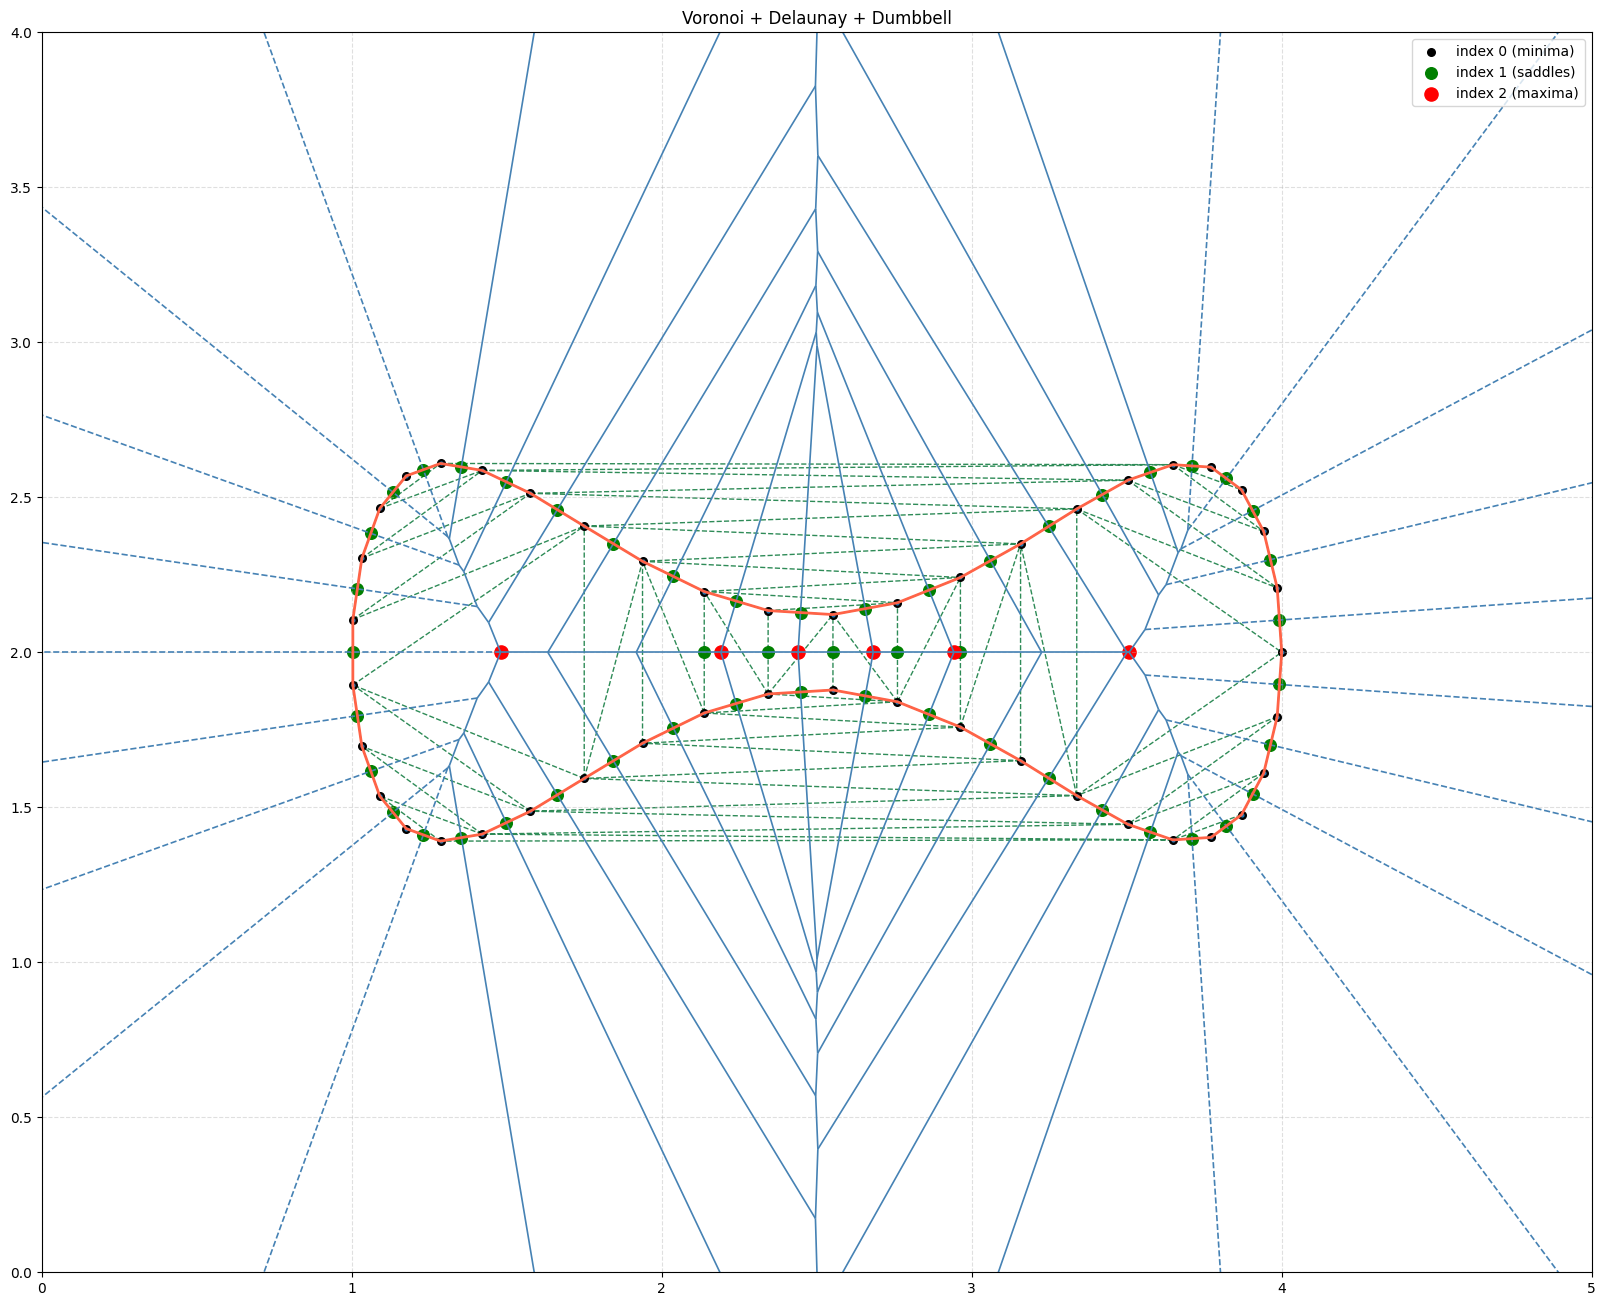

In [273]:



fig, ax = plt.subplots(figsize=(20, 20))

# Voronoi
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='steelblue', line_width=1.2, point_size=4)

# Delaunay
ax.triplot(points_array[:, 0], points_array[:, 1], tri.simplices, color='seagreen', linewidth=1, linestyle='--')

# Dumbbell outline
x = [p[0] for p in points]
y = [p[1] for p in points]
ax.plot(x + [x[0]], y + [y[0]], color='tomato', linewidth=2, zorder=3)

ax.set_xlim(0, 5)
ax.set_ylim(0, 4)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.4)
plt.title("Voronoi + Delaunay + Dumbbell")



# index 0: original points
ax.scatter(idx0[:, 0], idx0[:, 1],
           color='black', s=30, label='index 0 (minima)')

# index 1: saddle points (Gabriel edges)
if len(idx1) > 0:
    ax.scatter(idx1[:, 0], idx1[:, 1],
               color='green', s=70, label='index 1 (saddles)')

# index 2: triangle critical points
if len(idx2) > 0:
    ax.scatter(idx2[:, 0], idx2[:, 1],
               color='red', s=90, label='index 2 (maxima)')

ax.legend()

plt.show()

In [ ]:
simplices = tri.simplices


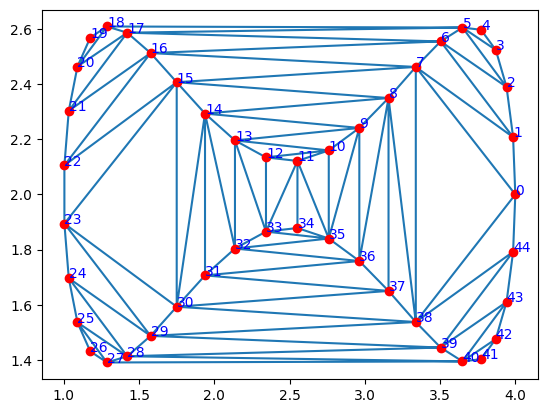

In [ ]:


plt.triplot(points_array[:, 0], points_array[:, 1], tri.simplices)

# plot points
plt.scatter(points_array[:, 0], points_array[:, 1], color='red')

# add labels (indices)
for i, (x, y) in enumerate(points_array):
    plt.text(x, y, str(i), color='blue', fontsize=10)

plt.show()

In [336]:
edges[40]

(11, 34)

In [334]:
edge_to_index[(11 , 34)]

40

In [ ]:
def simplex_to_edges(simplex):
    a, b, c = simplex
    return [
        tuple(sorted((a, b))),
        tuple(sorted((b, c))),
        tuple(sorted((a, c)))
    ]

In [ ]:
def edge_to_triangles(edge, simplices):
    u, v = sorted(edge)
    result = []

    for tri in simplices:
        if u in tri and v in tri:
            result.append(sorted(list(tri)))

    return result

In [ ]:
from collections import defaultdict

# ----------------------------
# Helpers
# ----------------------------

def normalize_simplex(s):
    return tuple(sorted(s))

def edges_of_triangle(t):
    a, b, c = t
    return [(a, b), (b, c), (c, a)]


# ----------------------------
# Precompute adjacency
# ----------------------------

def build_edge_to_triangles(simplices):
    edge_to_tris = defaultdict(list)

    for tri in simplices:
        tri = normalize_simplex(tri)

        a, b, c = tri
        edges = [(a, b), (b, c), (a, c)]

        for e in edges:
            e = tuple(sorted(e))
            edge_to_tris[e].append(tri)

    return edge_to_tris

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt



In [ ]:
def flow_complex(start_triangle, simplices, critical_edges):
    """
    start_triangle: list like [a,b,c]
    simplices: list of triangles
    critical_edges: list of edges like [[a,b], [c,d], ...]
    """

    edge_to_tris = build_edge_to_triangles(simplices)

    # normalize critical edges
    critical_edges = set(tuple(sorted(e)) for e in critical_edges)

    flow = []
    crit_edges_visited = []
    visited_tris = set()
    visited_edges = set()

    def dfs(tri):
        tri_n = normalize_simplex(tri)

        if tri_n in visited_tris:
            return

        visited_tris.add(tri_n)
        flow.append(list(tri_n))

        for edge in edges_of_triangle(tri_n):
            edge_n = tuple(sorted(edge))

            # skip critical edges
            if edge_n in critical_edges:
                crit_edges_visited.append(edge_n)
                continue


            # add edge to flow (only once)
            if edge_n not in visited_edges:
                visited_edges.add(edge_n)
                flow.append(list(edge_n))

                # move to adjacent triangle
                adj = edge_to_tris.get(edge_n, [])

                for nxt in adj:
                    if nxt != tri_n:
                        dfs(nxt)

    dfs(start_triangle)
    return flow , crit_edges_visited

In [ ]:
G = nx.Graph()


# Add nodes
for e in crit_edges:
    G.add_node(tuple(sorted(e)), kind="edge")

for t in crit_simplices:
    G.add_node(tuple(sorted(t)), kind="triangle")

In [ ]:



complete_flow_complex = []
for tri in crit_simplices:
    flow, crit_edges_visited = flow_complex(tri, simplices, crit_edges)
    complete_flow_complex += [flow]
    for edge in crit_edges_visited:
        G.add_edge(tuple(sorted(tri)), tuple(sorted(edge)))


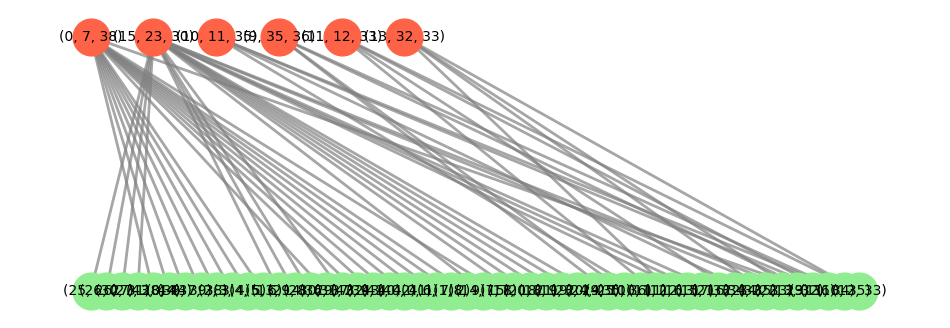

In [ ]:

pos = {}

# Top row: triangles
for i, t in enumerate(crit_simplices):
    pos[tuple(sorted(t))] = (4*i, 2)

# Bottom row: edges
for i, e in enumerate(crit_edges):
    pos[tuple(sorted(e))] = (i, 1)


# Separate nodes by type
triangle_nodes = [tuple(sorted(t)) for t in crit_simplices]
edge_nodes = [tuple(sorted(e)) for e in crit_edges]


# Draw
plt.figure(figsize=(12, 4))

nx.draw_networkx_nodes(
    G, pos,
    nodelist=triangle_nodes,
    node_color="tomato",
    node_size=700
    
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=edge_nodes,
    node_color="lightgreen",
    node_size=700
)


nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    width=2,
    alpha=0.7
)

nx.draw_networkx_labels(G, pos, font_size=10)

plt.axis("off")
plt.show()

In [ ]:
n_colours = len(complete_flow_complex )
n_colours

6

In [ ]:
colors = plt.cm.hsv(np.linspace(0, 1, n_colours))

In [ ]:
from matplotlib.patches import Polygon

def draw_triangle(ax, triangle_points, color, alpha=0.4):
    poly = Polygon(triangle_points,
                   closed=True,
                   facecolor=color,
                   edgecolor=color,
                   alpha=alpha)
    ax.add_patch(poly)

In [ ]:
complete_flow_complex[0]

[[0, 7, 38],
 [0, 7],
 [0, 1, 7],
 [1, 7],
 [1, 6, 7],
 [1, 6],
 [1, 2, 6],
 [2, 6],
 [2, 5, 6],
 [2, 5],
 [2, 3, 5],
 [3, 5],
 [3, 4, 5],
 [7, 38],
 [7, 8, 38],
 [8, 38],
 [8, 37, 38],
 [8, 37],
 [8, 36, 37],
 [8, 36],
 [8, 9, 36],
 [0, 38],
 [0, 38, 44],
 [38, 44],
 [38, 39, 44],
 [39, 44],
 [39, 43, 44],
 [39, 43],
 [39, 40, 43],
 [40, 43],
 [40, 42, 43],
 [40, 42],
 [40, 41, 42]]

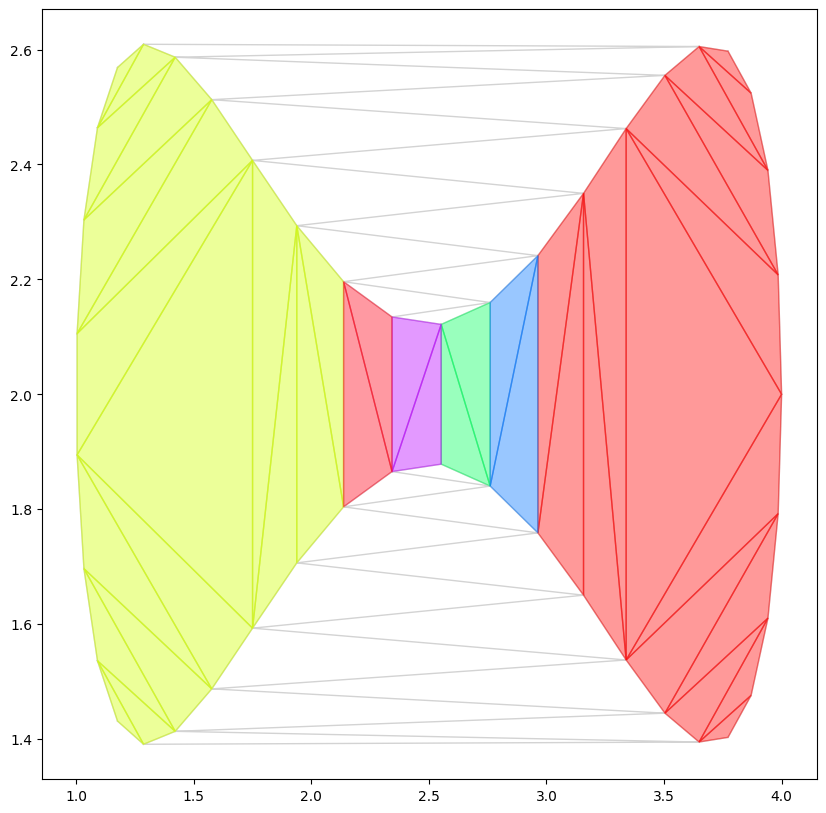

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.triplot(points_array[:, 0], points_array[:, 1],
           simplices, color='lightgray', linewidth=1)

for i in range(n_colours):
    for tri in complete_flow_complex[i]:
        if len(tri) == 3:   # triangle indices
            tri_pts = points_array[np.array(tri)]
            draw_triangle(ax, tri_pts, colors[i])


In [339]:
e = 0
t = 0
for i in complete_flow_complex[0]:
    if len(i) == 2:
        e += 1
    elif len(i) == 3:
        t += 1
print(e,t)

16 17


In [283]:
complete_flow_complex[0][0]

[0, 7, 38]

In [284]:
complete_index_flow = []

for flow in complete_flow_complex:
    index_flow = []
    for s in flow:
        s = tuple(sorted(s))
        if len(s) == 2:
            index_flow.append((1, edge_to_index[s]))
        elif len(s) == 3:
            index_flow.append((2, triangle_to_index[s]))
    complete_index_flow.append(index_flow)


In [341]:
points

[(4.0, 2.0),
 (3.9854021031123557, 2.2077691825277608),
 (3.9418925439074783, 2.389650246151078),
 (3.8703181864639014, 2.5240360029489297),
 (3.772072144234639, 2.597144717568502),
 (3.6490666646784673, 2.605219067877227),
 (3.5036959095382874, 2.5550029062767408),
 (3.3387893552061203, 2.4624167508870856),
 (3.1575567201836163, 2.349664109974393),
 (2.963525491562421, 2.2412717243563565),
 (2.7604722665003956, 2.1597507525911843),
 (2.5523492450537515, 2.121631025320079),
 (2.34320730509852, 2.134555510119785),
 (2.1371171566004983, 2.1959383024326304),
 (1.9380901098761318, 2.29341858656986),
 (1.7500000000000004, 2.407031939778686),
 (1.5765077870115125, 2.5127228792716894),
 (1.4209902994920232, 2.5865901230328165),
 (1.286474508437579, 2.6091288492807663),
 (1.1755786107116095, 2.5687342978882644),
 (1.0904610688211376, 2.463858358687618),
 (1.0327785988992915, 2.3034433329867126),
 (1.0036539246102638, 2.105554634445955),
 (1.0036539246102638, 1.8944453655540454),
 (1.0327785988

In [343]:


with open("points.nodes", "w") as f:
    # First line: number of points, dimension, attributes, boundary markers
    f.write(f"{len(points)} 3 0 0\n")

    # Points: index x y z
    for i, (x, y) in enumerate(points, start=1):
        f.write(f"{i} {x} {y} 0\n")

In [353]:
for i in range(n_colours):
    file_name = "sub_complex_" + str(i) + ".sub"
    with open(file_name, "w") as f:
        for j in complete_index_flow[i]:
            f.write(f"{j[0]} {j[1]}\n")

In [366]:
crit_edges[i]

(12, 33)

In [370]:
len(edge_to_index)

111

In [371]:
for i in range(len(crit_edges)):
    file_name = "sub_complex_" + str(i + n_colours) + ".sub"
    with open(file_name, "w") as f:
        f.write(f"{1} {edge_to_index[crit_edges[i]]}\n")
    

In [372]:
import zipfile

with zipfile.ZipFile("sub_complexes.zip", "w") as zipf:

    for i in range(n_colours):
        file_name = "sub_complex_" + str(i) + ".sub"

        content = ""
        for j in complete_index_flow[i]:
            content += f"{j[0]} {j[1]}\n"

        zipf.writestr(file_name, content)

    for i in range(len(crit_edges)):
        file_name = "sub_complex_" + str(i + n_colours) + ".sub"

        content = f"1 {edge_to_index[crit_edges[i]]}\n"

        zipf.writestr(file_name, content)